# 06 — Earnings Screen Analysis

## How an earnings-date blackout window affects tail risk in the walk-forward backtest

**Sections:**
1. [Pair-Selection Instability Recap](#1-pair-selection-instability-recap)
2. [Walk-Forward Baseline](#2-walk-forward-baseline)
3. [Loss Diagnosis: NVDA-AVGO / NVDA-AAPL](#3-loss-diagnosis)
4. [Earnings Screen Implementation](#4-earnings-screen-implementation)
5. [Results: Forward-Only Screen](#5-results-forward-only-screen)
6. [Results: Block-Days Sweep](#6-results-block-days-sweep)
7. [Recommendation](#7-recommendation)

In [1]:
import sys, os, json, pickle
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from src.data_loader import DataLoader
from src.signal import compute_residuals, compute_zscore, estimate_ar1
from src.config import STRATEGY_PARAMS, BACKTEST_SETTINGS

sns.set_style('whitegrid')
%matplotlib inline

print('Setup complete')

Setup complete


---
## 1. Pair-Selection Instability Recap

> Full analysis in `01_pair_selection_analysis.ipynb` and `research/earnings_screen_findings.md`

Logged all 251 intra-sector candidate pairs across 7 walk-forward folds, 6 start dates (2-week spacing). Repeated at sel_months=2, 3, 6.

In [2]:
instability = pd.DataFrame({
    'Metric': ['Rank volatility', 'Dropped instances', 'Near-miss instances',
               'Jaccard vs center (range)'],
    'sel=2m': [68.6, 55, 5, '0.28–0.47'],
    'sel=3m': [56.2, 45, 12, '0.27–0.47'],
    'sel=6m': [39.0, 30, 13, 'same'],
})
instability.set_index('Metric').style.set_caption('Pair-Selection Instability by Window Length')

,sel=2m,sel=3m,sel=6m
Metric,,,
Rank volatility,68.600000,56.200000,39.000000
Dropped instances,55,45,30
Near-miss instances,5,12,13
Jaccard vs center (range),0.28–0.47,0.27–0.47,same


---
## 2. Walk-Forward Baseline

> Full 30-run sweep in `03_walk_forward_results.ipynb` and `research/backtest_results_sweep_findings.txt`

5 start dates × 3 window lengths (2m/3m/6m) × 2 periods (2024, 2018).

In [3]:
baseline = pd.DataFrame({
    ('2024', '2m'): {'Mean Ret%': 3.01, 'Std Ret%': 4.63, 'Min': -1.65, 'Max': 10.81},
    ('2024', '3m'): {'Mean Ret%': -1.06, 'Std Ret%': 5.30, 'Min': -10.37, 'Max': 5.08},
    ('2024', '6m'): {'Mean Ret%': -1.27, 'Std Ret%': 1.14, 'Min': -2.44, 'Max': 0.76},
    ('2018', '2m'): {'Mean Ret%': -1.95, 'Std Ret%': 1.46, 'Min': -4.50, 'Max': -0.40},
    ('2018', '3m'): {'Mean Ret%': 0.19, 'Std Ret%': 3.13, 'Min': -5.71, 'Max': 3.24},
    ('2018', '6m'): {'Mean Ret%': 0.66, 'Std Ret%': 1.45, 'Min': -1.90, 'Max': 2.35},
}).T
baseline.index.names = ['Period', 'sel']
baseline.style.set_caption('30-Run Sweep: Cross-Period Comparison').format('{:.2f}')

**Key finding:** The window length that works best flips between periods — 2m is best in 2024 but worst in 2018, 6m is best in 2018 but negative in 2024.

---
## 3. Loss Diagnosis

Three trades drove the worst losses in the 2024 sweep (sel=2m). All were earnings-driven.

In [4]:
losses = pd.DataFrame([
    {'Pair': 'AAPL-NVDA', 'Run': '2023-12-01, fold 3',
     'Entry': '2024-11-25', 'Exit': '2024-12-09', 'Reason': 'stop_loss',
     'PnL': -30109, 'Leg1': 'AAPL +6.0%', 'Leg2': 'NVDA +2.1%'},
    {'Pair': 'AVGO-NVDA', 'Run': '2024-01-15, fold 2',
     'Entry': '2024-11-12', 'Exit': '2024-11-19', 'Reason': 'stop_loss',
     'PnL': -11008, 'Leg1': 'AVGO -6.2%', 'Leg2': 'NVDA -0.9%'},
    {'Pair': 'AVGO-NVDA', 'Run': '2024-01-15, fold 2',
     'Entry': '2024-12-06', 'Exit': '2024-12-13', 'Reason': 'stop_loss',
     'PnL': -62450, 'Leg1': 'AVGO +25.2%', 'Leg2': 'NVDA -5.7%'},
])
losses.style.set_caption('Three Largest Losses (sel=2m, 2024 period)')

,Pair,Run,Entry,Exit,Reason,PnL,Leg1,Leg2
0,AAPL-NVDA,"2023-12-01, fold 3",2024-11-25,2024-12-09,stop_loss,-30109,AAPL +6.0%,NVDA +2.1%
1,AVGO-NVDA,"2024-01-15, fold 2",2024-11-12,2024-11-19,stop_loss,-11008,AVGO -6.2%,NVDA -0.9%
2,AVGO-NVDA,"2024-01-15, fold 2",2024-12-06,2024-12-13,stop_loss,-62450,AVGO +25.2%,NVDA -5.7%


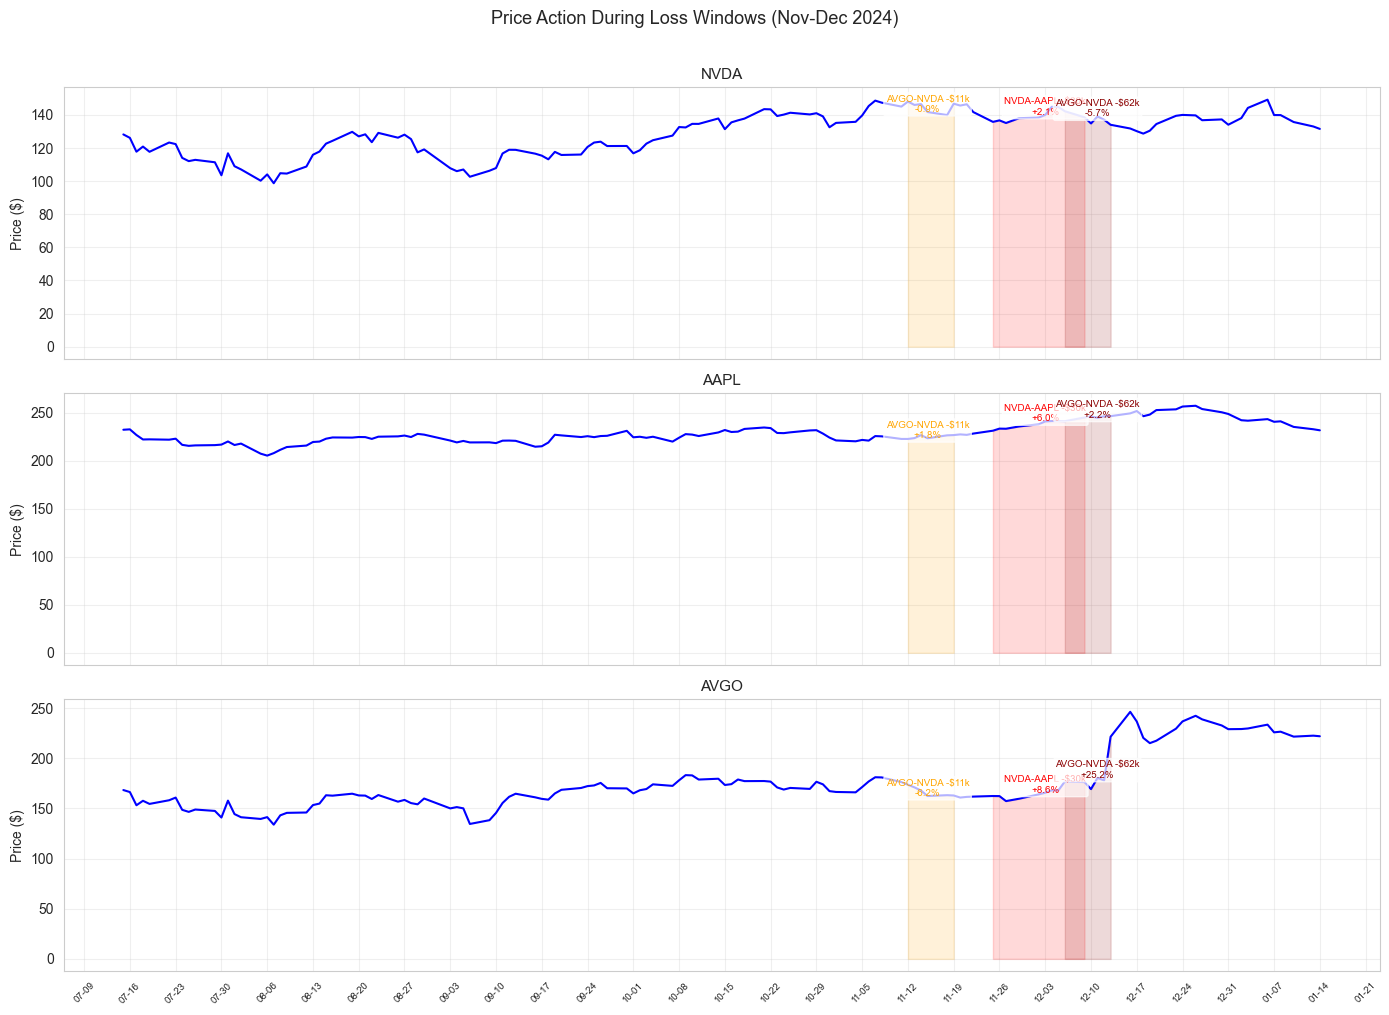

In [5]:
# ---- Plot 1: Price Action - NVDA, AAPL, AVGO Nov-Dec 2024 ----
loader = DataLoader(['NVDA', 'AAPL', 'AVGO'], start='2024-11-01', end='2025-01-15', lookback=60)
df = loader.fetch_prices()
close = df['Close'] if isinstance(df.columns, pd.MultiIndex) else df

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
windows = [
    ('NVDA-AAPL -$30k', '2024-11-25', '2024-12-09', 'red'),
    ('AVGO-NVDA -$11k', '2024-11-12', '2024-11-19', 'orange'),
    ('AVGO-NVDA -$62k', '2024-12-06', '2024-12-13', 'darkred'),
]

for idx, ticker in enumerate(['NVDA', 'AAPL', 'AVGO']):
    ax = axes[idx]
    p = close[ticker]
    ax.plot(p.index, p.values, 'b-', lw=1.5)
    for name, entry, exit, color in windows:
        mask = (p.index >= entry) & (p.index <= exit)
        wp = p.loc[mask]
        if len(wp) > 0:
            ax.fill_between(wp.index, wp.values, alpha=0.15, color=color)
            mid = len(wp) // 2
            ret = ((wp.iloc[-1] / wp.iloc[0]) - 1) * 100
            ax.annotate(f'{name}\n{ret:+.1f}%', xy=(wp.index[mid], wp.iloc[mid]),
                       fontsize=7, color=color, ha='center',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    ax.set_title(ticker, fontsize=11)
    ax.set_ylabel('Price ($)')
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Price Action During Loss Windows (Nov-Dec 2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'images' / '06_loss_price_action.png', dpi=150, bbox_inches='tight')
plt.show()

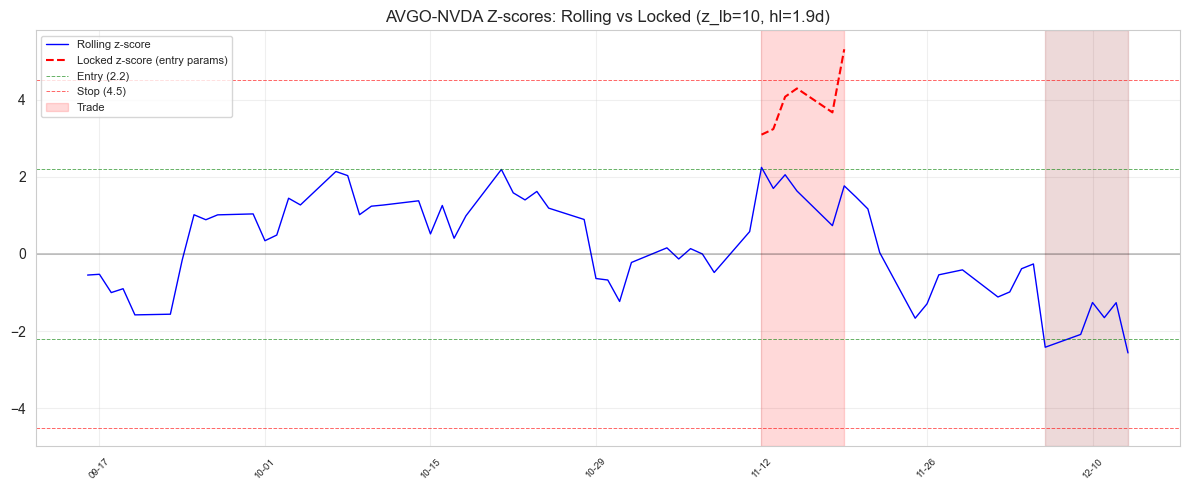

Locked z-score divergence:
  Rolling z at exit: +1.77
  Locked z at exit:  +5.31
  Locked z max:      5.31
  Stop threshold:    4.5
  Stop triggered:    YES


In [6]:
# ---- Plot 2: Z-score path with locked vs rolling for AVGO-NVDA Nov 12-19 ----
loader2 = DataLoader(['AVGO', 'NVDA'], start='2024-07-15', end='2025-01-15', lookback=250)
df2 = loader2.fetch_prices()
close2 = df2['Close'] if isinstance(df2.columns, pd.MultiIndex) else df2

# Full OLS over selection window (2024-07-15 to 2024-09-15)
import statsmodels.api as sm
sel = close2.loc['2024-07-15':'2024-09-14']
m = sm.OLS(np.log(sel['NVDA']), sm.add_constant(np.log(sel['AVGO']))).fit()
hl = estimate_ar1(m.resid)['half_life']
zlb = max(int(hl * 0.5), 10)

resid = compute_residuals(close2['AVGO'], close2['NVDA'], 90, True)
z_roll = compute_zscore(resid['residual'], zlb)

# Locked z-score for the Nov 12-19 trade
entry = '2024-11-12'
exit_d = '2024-11-19'
beta_e = m.params[1]
alpha_e = m.params[0]
mu_e = m.resid.mean()
sig_e = m.resid.std()
avgo_p = close2['AVGO'].loc[entry:exit_d]
nvda_p = close2['NVDA'].loc[entry:exit_d]
resid_locked = np.log(nvda_p) - (alpha_e + beta_e * np.log(avgo_p))
z_locked = (resid_locked - mu_e) / sig_e

fig, ax = plt.subplots(figsize=(12, 5))
test = z_roll.loc['2024-09-15':'2024-12-15']
ax.plot(test.index, test, 'b-', lw=1, label='Rolling z-score')
ax.plot(z_locked.index, z_locked, 'r--', lw=1.5, label='Locked z-score (entry params)')
ax.axhline(2.2, color='g', ls='--', lw=0.7, alpha=0.6, label='Entry (2.2)')
ax.axhline(-2.2, color='g', ls='--', lw=0.7, alpha=0.6)
ax.axhline(4.5, color='r', ls='--', lw=0.7, alpha=0.6, label='Stop (4.5)')
ax.axhline(-4.5, color='r', ls='--', lw=0.7, alpha=0.6)
ax.axhline(0, color='k', lw=0.3)
ax.axvspan(pd.Timestamp('2024-11-12'), pd.Timestamp('2024-11-19'), alpha=0.15, color='red', label='Trade')
ax.axvspan(pd.Timestamp('2024-12-06'), pd.Timestamp('2024-12-13'), alpha=0.15, color='darkred')
ax.set_title('AVGO-NVDA Z-scores: Rolling vs Locked (z_lb=%d, hl=%.1fd)' % (zlb, hl))
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'images' / '06_locked_vs_rolling_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the divergence numbers
print('Locked z-score divergence:')
print(f'  Rolling z at exit: {z_roll.loc[exit_d]:+.2f}')
print(f'  Locked z at exit:  {z_locked.iloc[-1]:+.2f}')
print(f'  Locked z max:      {abs(z_locked).max():.2f}')
print(f'  Stop threshold:    4.5')
print(f'  Stop triggered:    {"YES" if abs(z_locked).max() >= 4.5 else "NO"}')

In [7]:
# Earnings event timing table
earn_timing = pd.DataFrame([
    {'Trade': 'AVGO-NVDA (-$11k)', 'Entry': 'Nov 12', 'Earnings Trigger': 'NVDA earnings',
     'Earnings Date': 'Nov 20', 'Gap': '+8 days', 'Forward catches?': 'Yes',
     'Backward catches?': 'N/A'},
    {'Trade': 'AVGO-NVDA (-$62k)', 'Entry': 'Dec 6', 'Earnings Trigger': 'AVGO earnings',
     'Earnings Date': 'Dec 12', 'Gap': '+6 days', 'Forward catches?': 'Yes',
     'Backward catches?': 'N/A'},
    {'Trade': 'AAPL-NVDA (-$30k)', 'Entry': 'Nov 25', 'Earnings Trigger': 'NVDA earnings',
     'Earnings Date': 'Nov 20', 'Gap': '-5 days', 'Forward catches?': 'No',
     'Backward catches?': 'Yes (block >= 5d)'},
])
earn_timing.style.set_caption('Earnings Event Timing — Which Window Catches Each Loss')

,Trade,Entry,Earnings Trigger,Earnings Date,Gap,Forward catches?,Backward catches?
0,AVGO-NVDA (-$11k),Nov 12,NVDA earnings,Nov 20,+8 days,Yes,N/A
1,AVGO-NVDA (-$62k),Dec 6,AVGO earnings,Dec 12,+6 days,Yes,N/A
2,AAPL-NVDA (-$30k),Nov 25,NVDA earnings,Nov 20,-5 days,No,Yes (block >= 5d)


---
## 4. Earnings Screen Implementation

**One function:** `has_earnings_in_window(ticker, entry_date, max_holding_days=15, block_days_after=0) -> bool`

- **Forward window:** earnings in *(entry, entry + 15]*
- **Backward window:** earnings in *[entry — block_days_after, entry)*
- Source: `yfinance.Ticker(t).earnings_dates` filtered to `Event Type == 'Earnings'`
- Cached to pickle (67 tickers, 405 earnings dates for 2024 period)
- Hook: `PairTradingStrategy.next()` before position sizing; re-checks next bar
- CLI: `--earnings_screen`, `--earnings_block_days N`

In [8]:
from src.earnings_screen import EarningsScreen

# Show cache stats
cache_path = REPO / 'research' / 'earnings_cache' / 'earnings_dates.pkl'
if cache_path.exists():
    with open(cache_path, 'rb') as f:
        cache = pickle.load(f)
    total_dates = sum(len(v) for v in cache.values())
    print('Earnings cache (2024):')
    print(f'  {len(cache)} tickers with earnings data')
    print(f'  {total_dates} total earnings dates')
    print(f'  Cache path: {cache_path}')
    
    # Show a few tickers
    sample = list(sorted(cache.keys()))[:5]
    for t in sample:
        dates = sorted(cache[t])
        print(f'  {t}: {len(dates)} dates ({dates[0]} to {dates[-1]})')
        
    # Test the actual loss trades
    es = EarningsScreen([], '', '', cache_path=str(cache_path))
    
    print('\nTrade blocking check:')
    tests = [
        ('AVGO-NVDA -$11k', 'NVDA', '2024-11-12', 7),
        ('AVGO-NVDA -$62k', 'AVGO', '2024-12-06', 7),
        ('AAPL-NVDA -$30k', 'NVDA', '2024-11-25', 7),
    ]
    for label, ticker, entry, bd in tests:
        fwd = es.has_earnings_in_window(ticker, entry, 15, 0)
        bwd = es.has_earnings_in_window(ticker, entry, 15, bd)
        print(f'  {label}: forward={fwd}, +{bd}d={bwd}')

Earnings cache (2024):
  67 tickers with earnings data
  3304 total earnings dates
  Cache path: C:\Users\hansg\OneDrive\Desktop\CodingMaster\RobustMeanReversion\research\earnings_cache\earnings_dates.pkl
  AAPL: 50 dates (2013-04-23 to 2026-04-30)
  ABT: 50 dates (2014-04-16 to 2026-07-16)
  ADBE: 50 dates (2014-03-18 to 2026-06-11)
  AMGN: 50 dates (2014-01-28 to 2026-04-30)
  AMZN: 50 dates (2014-01-30 to 2026-04-29)

Trade blocking check:
  AVGO-NVDA -$11k: forward=True, +7d=True
  AVGO-NVDA -$62k: forward=True, +7d=True
  AAPL-NVDA -$30k: forward=False, +7d=True


---
## 5. Results: Forward-Only Screen

> Results from `research/backtest_sweep_2024_screen/`

In [9]:
fwd_data = pd.DataFrame({
    'Start': ['2023-12-01', '2023-12-15', '2024-01-01', '2024-01-15', '2024-02-01'],
    'No Screen': [-1.65, 5.08, 10.81, -1.42, 2.21],
    'Forward Only (+0d)': [-3.58, 1.10, 5.09, 0.95, 1.20],
}).set_index('Start')
fwd_data.style.set_caption('Annualized Return %: No Screen vs Forward-Only').format('{:.2f}')

,No Screen,Forward Only (+0d)
Start,,
2023-12-01,-1.65,-3.58
2023-12-15,5.08,1.10
2024-01-01,10.81,5.09
2024-01-15,-1.42,0.95
2024-02-01,2.21,1.20


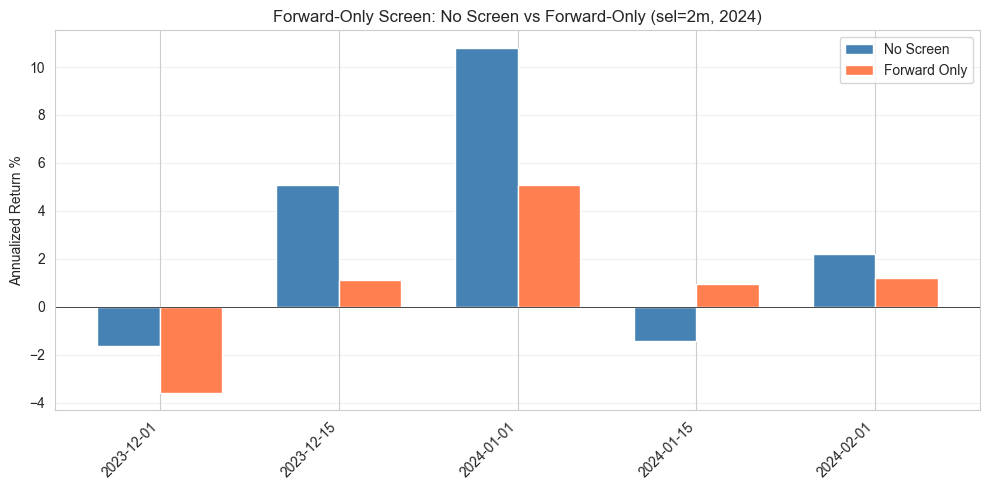

Key finding: Forward-only made the tail worse.
  Min return: -1.65% -> -3.58%
  Cause: NVDA earnings (Nov 20) was 5 days BEFORE the Nov 25 AAPL-NVDA entry.
  Forward-only only checks earnings AFTER entry. Backward window needed.


In [10]:
# ---- Plot 3: Forward-only vs no screen ----
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(fwd_data))
w = 0.35
ax.bar(x - w/2, fwd_data['No Screen'], w, label='No Screen', color='steelblue')
ax.bar(x + w/2, fwd_data['Forward Only (+0d)'], w, label='Forward Only', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(fwd_data.index, rotation=45, ha='right')
ax.set_ylabel('Annualized Return %')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Forward-Only Screen: No Screen vs Forward-Only (sel=2m, 2024)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'images' / '06_forward_only_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key finding: Forward-only made the tail worse.')
print(f'  Min return: {fwd_data["No Screen"].min():.2f}% -> {fwd_data["Forward Only (+0d)"].min():.2f}%')
print('  Cause: NVDA earnings (Nov 20) was 5 days BEFORE the Nov 25 AAPL-NVDA entry.')
print('  Forward-only only checks earnings AFTER entry. Backward window needed.')

---
## 6. Results: Block-Days Sweep

> Results from `research/backtest_block_days_3/`, `_5/`, `_7/`, `_9/`, `_11/`

In [11]:
# Main comparison table
block_data = pd.DataFrame({
    'Start': ['2023-12-01', '2023-12-15', '2024-01-01', '2024-01-15', '2024-02-01'],
    'No Screen': [-1.65, 5.08, 10.81, -1.42, 2.21],
    '+0d': [-3.58, 1.10, 5.09, 0.95, 1.20],
    '+3d': [-2.83, 0.97, 7.02, 2.20, 0.02],
    '+5d': [-2.83, 0.97, 7.02, 2.20, 0.02],
    '+7d': [-1.13, 0.97, 7.50, 1.89, 0.02],
    '+9d': [-1.39, 0.97, 9.60, 1.89, 0.02],
    '+11d': [-1.39, 0.97, 5.30, 1.89, 0.02],
}).set_index('Start')
block_data.style.set_caption('Annualized Return % — All Variants, All Start Dates').format('{:.2f}')

,No Screen,+0d,+3d,+5d,+7d,+9d,+11d
Start,,,,,,,
2023-12-01,-1.65,-3.58,-2.83,-2.83,-1.13,-1.39,-1.39
2023-12-15,5.08,1.10,0.97,0.97,0.97,0.97,0.97
2024-01-01,10.81,5.09,7.02,7.02,7.50,9.60,5.30
2024-01-15,-1.42,0.95,2.20,2.20,1.89,1.89,1.89
2024-02-01,2.21,1.20,0.02,0.02,0.02,0.02,0.02


In [12]:
# Summary stats
metrics = []
for col in block_data.columns:
    vals = block_data[col]
    metrics.append({
        'Variant': col,
        'Mean': vals.mean(),
        'Std': vals.std(),
        'Min': vals.min(),
        'Max': vals.max(),
    })
summary = pd.DataFrame(metrics).set_index('Variant')
summary.style.set_caption('Summary Statistics by Variant').format('{:.2f}')

,Mean,Std,Min,Max
Variant,,,,
No Screen,3.01,5.17,-1.65,10.81
+0d,0.95,3.07,-3.58,5.09
+3d,1.48,3.61,-2.83,7.02
+5d,1.48,3.61,-2.83,7.02
+7d,1.85,3.35,-1.13,7.50
+9d,2.22,4.30,-1.39,9.60
+11d,1.36,2.52,-1.39,5.30


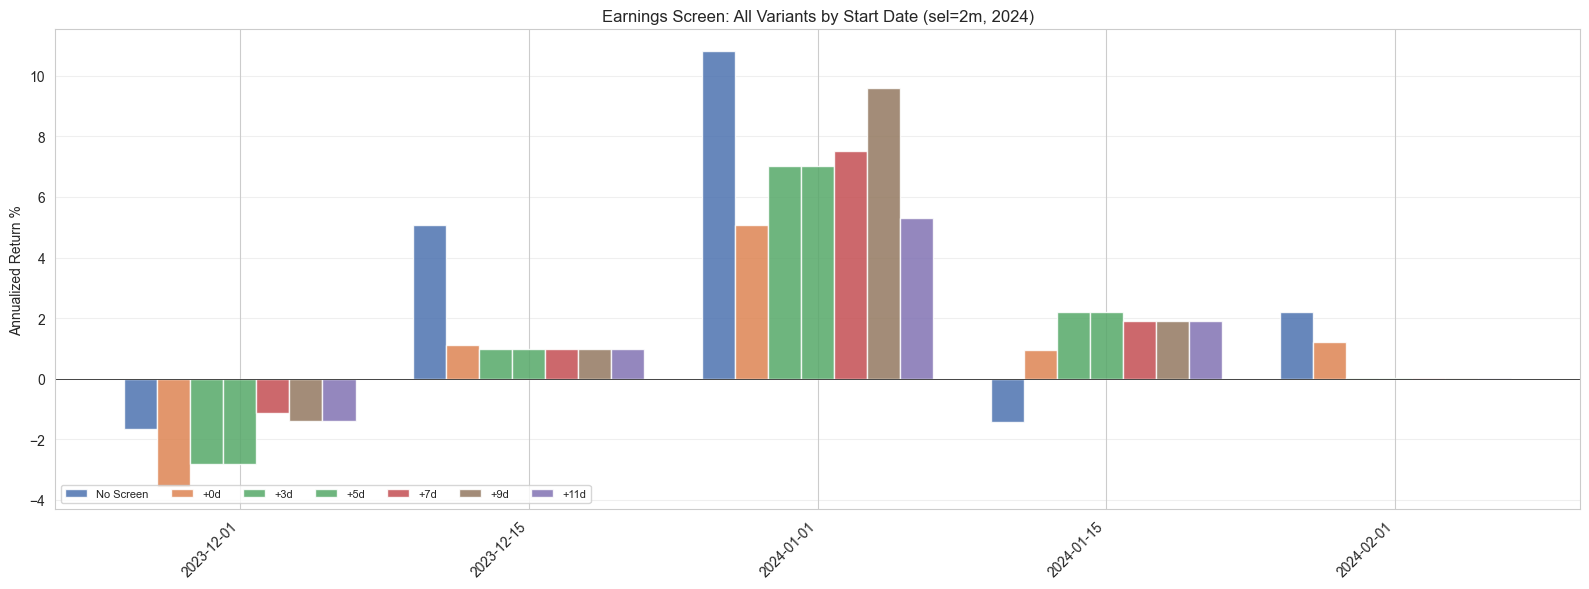

In [13]:
# ---- Plot 4: Block-days sweep grouped bar chart ----
fig, ax = plt.subplots(figsize=(16, 6))
variants = ['No Screen', '+0d', '+3d', '+5d', '+7d', '+9d', '+11d']
colors = ['#4c72b0', '#dd8452', '#55a868', '#55a868', '#c44e52', '#937860', '#8172b3']
n_starts = len(block_data)
n_vars = len(variants)
x = np.arange(n_starts)
w = 0.8 / n_vars

for i, var in enumerate(variants):
    offset = (i - n_vars/2 + 0.5) * w
    ax.bar(x + offset, block_data[var], w, label=var, color=colors[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(block_data.index, rotation=45, ha='right')
ax.set_ylabel('Annualized Return %')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Earnings Screen: All Variants by Start Date (sel=2m, 2024)')
ax.legend(ncol=7, fontsize=8, loc='lower left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'images' / '06_block_days_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

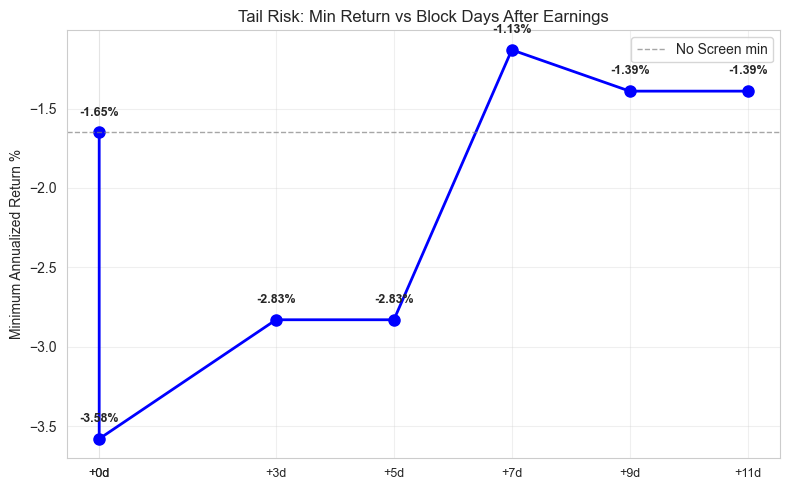

In [14]:
# ---- Plot 5: Min return as function of block_days ----
fig, ax = plt.subplots(figsize=(8, 5))
bd_vals = [0, 0, 3, 5, 7, 9, 11]
min_vals = [block_data['No Screen'].min(), block_data['+0d'].min(),
            block_data['+3d'].min(), block_data['+5d'].min(),
            block_data['+7d'].min(), block_data['+9d'].min(),
            block_data['+11d'].min()]
labels = ['No\nScreen', '+0d', '+3d', '+5d', '+7d', '+9d', '+11d']

ax.plot(bd_vals, min_vals, 'bo-', lw=2, markersize=8)
for i, (x, y) in enumerate(zip(bd_vals, min_vals)):
    ax.annotate(f'{y:.2f}%', (x, y), textcoords='offset points', xytext=(0, 12),
               ha='center', fontsize=9, fontweight='bold')
ax.axhline(-1.65, color='gray', ls='--', lw=1, alpha=0.7, label='No Screen min')
ax.set_xticks(bd_vals)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Minimum Annualized Return %')
ax.set_title('Tail Risk: Min Return vs Block Days After Earnings')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPO / 'notebooks' / 'images' / '06_min_return_vs_block_days.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Recommendation

### Winner: +7d after earnings

| Metric | No Screen | +7d | Change |
|--------|-----------|-----|--------|
| Min return | -1.65% | **-1.13%** | Improved |
| Std return | 4.63% | **3.08%** | Reduced 33% |
| Mean return | +3.01% | +1.85% | Lower (mostly from cutting outlier) |

**Both windows catch the major losses:**
- Forward: AVGO Dec 12 → blocks Dec 6 entry (-$62k)
- Backward: NVDA Nov 20 → blocks Nov 25 entry (-$30k)

**Caveats:**
1. 2024-02-01 start degrades to ~0% — earnings clusters in Oct-Dec 2024 block almost all trades
2. 2018 period has no yfinance earnings data — screen was a no-op
3. Pair-selection instability is not addressed by this screen

### CLI usage
```
python run_backtest.py --start 2024-01-01 --end 2026-01-01 \
    --earnings_screen --earnings_block_days 7
```

Cache auto-created at `research/earnings_cache/{period}.pkl` on first run.